In [100]:
import pandas as pd
import numpy as np
import yfinance as yf
import matplotlib.pyplot as plt
from utils.financials import safe_get
from utils.formatting import calculate_scale, format_value
from variables import COMPANY, COLUMN_MAPPING, COLORS

In [101]:
try:
    BalanceSheet = COMPANY.balance_sheet
    IncomeStat = COMPANY.income_stmt
    CashFlowStat = COMPANY.cash_flow

    df_bal = BalanceSheet.T
    df_inc = IncomeStat.T
    df_cfs = CashFlowStat.T

    df_all = pd.concat([df_bal, df_inc, df_cfs], axis=1, sort=False)
    df_all = df_all.loc[:, ~df_all.columns.duplicated()]

    df_all = df_all.sort_index()

except Exception as e:
    print(f"Error while fetching or assembling financial statements: {e}")
    df_all = pd.DataFrame()

In [102]:
try:
    df = df_all.iloc[-10:, 3:].apply(pd.to_numeric, errors="coerce")
    df.index = pd.to_datetime(df.index).year
    df.columns = df.columns.str.lower().str.replace(" ", "_")

    df_all = df_all.map(format_value)

except Exception as e:
    print(f"Error while preparing/formatting financial data: {e}")
    df = pd.DataFrame()

In [103]:
try:
    current_assets = safe_get(df, COLUMN_MAPPING["current_assets"])
    current_liabilities = safe_get(df, COLUMN_MAPPING["current_liabilities"])

    cash_equivalents = safe_get(df, COLUMN_MAPPING["cash_equivalents"])
    short_term_investments = safe_get(df, COLUMN_MAPPING["short_term_investments"])

    total_cash_and_investments = cash_equivalents + short_term_investments

    if (total_cash_and_investments == 0).all():
        total_cash_and_investments = safe_get(df, COLUMN_MAPPING["cash_and_investments"])

    restricted_cash = safe_get(df, COLUMN_MAPPING["restricted_cash"])
    operating_current_assets = current_assets - total_cash_and_investments - restricted_cash

    current_debt = safe_get(df, COLUMN_MAPPING["current_debt"])

    operating_current_liabilities = current_liabilities - current_debt

    df["ncwc"] = operating_current_assets - operating_current_liabilities

except Exception as e:
    print(f"Error while calculating net core working capital (ncwc): {e}")
    total_cash_and_investments = pd.Series(dtype=float)

In [104]:
try:
    df["revenue_growth"] = df.total_revenue.pct_change()
    df["delta_ncwc"] = df.ncwc.diff()
    df.loc[df.index[1], "delta_ncwc"] = np.nan
    df["ebit_margin"] = df.ebit / df.total_revenue
    df["d_and_a_percent_of_sales"] = df.depreciation_and_amortization / df.total_revenue
    df["capital_expenditure"] = df.capital_expenditure.abs()
    df["capex_percent_of_sales"] = df.capital_expenditure / df.total_revenue
    df["delta_ncwc_percent_of_sales"] = df.delta_ncwc / df.total_revenue
    df["effective_tax_rate"] = df.tax_provision / df.ebit
    df["nopat"] = df.ebit - df.tax_provision

except Exception as e:
    print(f"Error while calculating derived financial ratios and base year assumptions: {e}")

In [105]:
try:
    base_year = df.iloc[-1, :]

    base_year.effective_tax_rate = 0.23
    base_year.delta_ncwc_percent_of_sales = df.delta_ncwc_percent_of_sales.mean()

    display(
        base_year[
            [
                "revenue_growth",
                "ebit_margin",
                "d_and_a_percent_of_sales",
                "capex_percent_of_sales",
                "effective_tax_rate",
                "delta_ncwc_percent_of_sales"
            ]
        ].map(format_value)
    )

except Exception as e:
    print(f"Error while calculating and displaying base year assumptions: {e}")
    base_year = pd.Series(dtype=float)

revenue_growth                 0.04
ebit_margin                    0.16
d_and_a_percent_of_sales       0.04
capex_percent_of_sales         0.03
effective_tax_rate             0.23
delta_ncwc_percent_of_sales    0.01
Name: 2025, dtype: str

In [106]:
n = 5
revenue_growth_T = 0.10
ebit_perc_T = 0.15
tax_perc_T = 0.23
dna_perc_T = 0.03
capex_perc_T = 0.03
ncwc_perc_T = -0.01
tgr = 0.02

In [107]:
def interpolate(initial_value, terminal_value, nyears):
    return np.linspace(initial_value, terminal_value, nyears)

In [108]:
try:
    years = range(df.index[-1] + 1, df.index[-1] + n + 1)
    df_proj = pd.DataFrame(index=years)

    df_proj["revenue_growth"] = interpolate(base_year.revenue_growth, revenue_growth_T, n)
    df_proj["ebit_margin"] = interpolate(base_year.ebit_margin, ebit_perc_T, n)
    df_proj["d_and_a_percent_of_sales"] = interpolate(base_year.d_and_a_percent_of_sales, dna_perc_T, n)
    df_proj["capex_percent_of_sales"] = interpolate(base_year.capex_percent_of_sales, capex_perc_T, n)
    df_proj["effective_tax_rate"] = interpolate(base_year.effective_tax_rate, tax_perc_T, n)
    df_proj["delta_ncwc_percent_of_sales"] = interpolate(base_year.delta_ncwc_percent_of_sales, ncwc_perc_T, n)

    df_proj["revenue_growth"] = [0.055, 0.086, 0.07, 0.07, 0.06]
    df_proj["ebit_margin"] = [0.126, 0.129, 0.129, 0.129, 0.129]
    df_proj["d_and_a_percent_of_sales"] = [0.042, 0.041, 0.04, 0.038, 0.038]
    df_proj["capex_percent_of_sales"] = [0.03, 0.03, 0.03, 0.03, 0.03]
    df_proj["effective_tax_rate"] = [0.23, 0.23, 0.23, 0.23, 0.23]

    df_proj["delta_ncwc_percent_of_sales"] = [0.015, 0.021, 0.022, 0.024, 0.022]
    df_proj["delta_ncwc_percent_of_sales"] = [0.0088, 0.0134, 0.0111, 0.0111, 0.0096]

    df_proj["total_revenue"] = base_year.total_revenue * (1 + df_proj.revenue_growth).cumprod()
    df_proj["ebit"] = df_proj.total_revenue * df_proj.ebit_margin
    df_proj["operating_margin"] = df_proj.ebit / df_proj.total_revenue
    df_proj["capital_expenditure"] = df_proj.total_revenue * df_proj.capex_percent_of_sales
    df_proj["depreciation_and_amortization"] = (df_proj.total_revenue * df_proj.d_and_a_percent_of_sales)
    df_proj["delta_ncwc"] = df_proj.total_revenue * df_proj.delta_ncwc_percent_of_sales
    df_proj["tax_provision"] = df_proj.ebit * df_proj.effective_tax_rate
    df_proj["nopat"] = df_proj.ebit - df_proj.tax_provision

    df_proj["other_cash_flow_adjustments"] = 5 * [0]

    df_proj["free_cash_flow"] = (
            df_proj.nopat
            + df_proj.depreciation_and_amortization
            - df_proj.capital_expenditure
            - df_proj.delta_ncwc
            + df_proj.other_cash_flow_adjustments
    )

except Exception as e:
    print(f"Error while building financial projections: {e}")
    df_proj = pd.DataFrame()

In [109]:
df_proj[
    [
        "nopat",
        "ebit",
        "tax_provision",
        "total_revenue",
        "operating_margin",
        "depreciation_and_amortization",
        "capital_expenditure",
        "delta_ncwc",
        "other_cash_flow_adjustments"
    ]
].map(format_value)

,nopat,ebit,tax_provision,total_revenue,operating_margin,depreciation_and_amortization,capital_expenditure,delta_ncwc,other_cash_flow_adjustments
2026,8.08B,10.49B,2.41B,83.25B,0.13,3.50B,2.50B,732.64M,0.00
2027,8.98B,11.66B,2.68B,90.41B,0.13,3.71B,2.71B,1.21B,0.00
2028,9.61B,12.48B,2.87B,96.74B,0.13,3.87B,2.90B,1.07B,0.00
2029,10.28B,13.35B,3.07B,103.52B,0.13,3.93B,3.11B,1.15B,0.00
2030,10.90B,14.15B,3.26B,109.73B,0.13,4.17B,3.29B,1.05B,0.00


In [110]:
try:
    dcf_columns = [
        "total_revenue",
        "revenue_growth",
        "ebit",
        "ebit_margin",
        "tax_provision",
        "effective_tax_rate",
        "nopat",
        "depreciation_and_amortization",
        "d_and_a_percent_of_sales",
        "capital_expenditure",
        "capex_percent_of_sales",
        "delta_ncwc",
        "delta_ncwc_percent_of_sales",
        "free_cash_flow",
    ]

    df_proj = df_proj[dcf_columns]

except Exception as e:
    print(f"Error while selecting DCF columns from projections: {e}")

In [111]:
try:
    beta = COMPANY.info.get("beta")
    market_cap = COMPANY.info.get("marketCap")

    us_10y = yf.Ticker("^TNX").history(period="5d")
    us_10y = us_10y["Close"]
    us_10y.rename("10Y", inplace=True)
    rf_rate = us_10y.iloc[-1] / 100

    erp = 0.0936 - rf_rate
    rf_rate = 0.03571

except Exception as e:
    print(f"Error while fetching market data for valuation inputs: {e}")
    beta = None
    market_cap = None
    rf_rate = None
    erp = None

In [112]:
print(f"Beta: {beta:.2f}")
print(f"Risk Free Rate: {rf_rate * 100:.2f}%")
print(f"ERP: {erp * 100:.2f}%")

Beta: 1.28
Risk Free Rate: 3.57%
ERP: 4.25%


In [113]:
try:
    total_debt = df.total_debt.iloc[-1]

    if total_debt > 0:
        interest_expense = abs(df.interest_expense.iloc[-1])
        cost_of_debt = interest_expense / total_debt
    else:
        cost_of_debt = 0

    print(f"Cost of Debt: {cost_of_debt * 100:.2f}%")

except Exception as e:
    print(f"Error while calculating cost of debt: {e}")
    total_debt = None
    cost_of_debt = None

Cost of Debt: 2.93%


In [114]:
try:
    cost_of_equity = beta * erp + rf_rate

    print(f"Cost of Equity: {cost_of_equity * 100:.2f}%")

except Exception as e:
    print(f"Error while calculating cost of equity: {e}")
    cost_of_equity = None

Cost of Equity: 9.02%


In [115]:
try:
    assets = base_year.total_assets
    debt = base_year.total_debt
    total = market_cap + debt
    after_tax_cost_of_debt = cost_of_debt * (1 - tax_perc_T)
    wacc = (after_tax_cost_of_debt * debt / total) + (cost_of_equity * market_cap / total)

    print(f"WACC: {wacc * 100:.2f}%")

except Exception as e:
    print(f"Error while calculating WACC: {e}")
    debt = None
    wacc = None

WACC: 7.61%


In [116]:
try:
    def calculate_present_value(cash_flows, discount_rate):
        return [cf / (1 + discount_rate) ** t for t, cf in enumerate(cash_flows, start=1)]


    df_proj["pv_free_cash_flow"] = calculate_present_value(df_proj.free_cash_flow.values, wacc)

except Exception as e:
    print(f"Error while calculating present value of free cash flows: {e}")

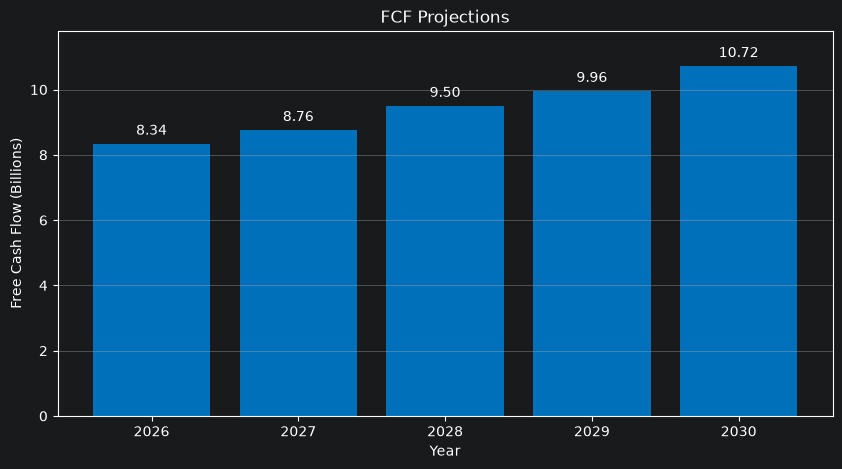

In [117]:
try:
    scale, unit = calculate_scale(df_proj.free_cash_flow.abs().max())

    plt.figure(figsize=(10, 5))

    bars = plt.bar(
        df_proj.index,
        df_proj.free_cash_flow / scale,
        color=COLORS["blue"]
    )

    plt.bar_label(bars, fmt="%.2f", padding=4)

    plt.title("FCF Projections")
    plt.xlabel("Year")
    plt.ylabel(f"Free Cash Flow ({unit})")

    plt.xticks(df_proj.index)
    plt.margins(y=0.1)

    plt.grid(axis="y")

    plt.show()

except Exception as e:
    print(f"Error while plotting FCF projections: {e}")

In [118]:
try:
    terminal_value = df_proj.free_cash_flow.values[-1] * (1 + tgr) / (wacc - tgr)
    pv_terminal_value = terminal_value / (1 + wacc) ** n

except Exception as e:
    print(f"Error while calculating terminal value: {e}")
    terminal_value = None
    pv_terminal_value = None

In [119]:
try:
    enterprise_value = np.sum(df_proj.pv_free_cash_flow) + pv_terminal_value
    cash = total_cash_and_investments.iloc[-1]
    equity_value = enterprise_value - debt + cash

    shares_outstanding = COMPANY.get_shares_full().iloc[-1]
    implied_share_price = equity_value / shares_outstanding

    print(f"Implied Share Price: {implied_share_price:.2f}")

except Exception as e:
    print(f"Error while calculating implied share price: {e}")
    implied_share_price = None

Implied Share Price: 171.06


In [120]:
current_market_price = COMPANY.history(period="1d")["Close"].iloc[-1]
margin_of_safety = ((implied_share_price - current_market_price) / implied_share_price) * 100

print(f"Margin of Safety: {margin_of_safety:.2f}%")

Margin of Safety: -60.15%
